
ALIGNED BPX PARAMETER SUMMARY
Nominal capacity [Ah]: 1.0
Electrode one-pair area [m2]: 0.0025000000000000005
Number parallel: 20.0
Effective area [m2]: 0.05000000000000001
Initial SoC: 0.5
Contact resistance [Ohm]: 0.0
c_e0 [mol m-3]: 1200.0
D_e(c_e0) [m2 s-1]: 1.3619360000000014e-10
kappa_e(c_e0) [S m-1]: 0.9194409135888804
Negative j0_ref [A m-2]: 472.12791545584076
Positive j0_ref [A m-2]: 0.9929425876308905

Grouped parameters:
Series resistance [Ohm]: 0.009068874479398236
Negative electrode charge transfer time scale [s]: 51.020251764157045
Positive electrode charge transfer time scale [s]: 10319.899856368545
Negative particle diffusion time scale [s]: 2140.2264687560596
Positive particle diffusion time scale [s]: 2832.2577428948116
Reference electrolyte capacity [A.s]: 439.04685529390997
Measured cell capacity [A.s]: 3600.0
Measured cell capacity from grouping [A.s]: 3600.0
Grouped metadata: {'tau_ct_mode': 'from_bpx_j0', 'tau_ct_multiplier': 1.0, 'use_total_area_for_grouping': 

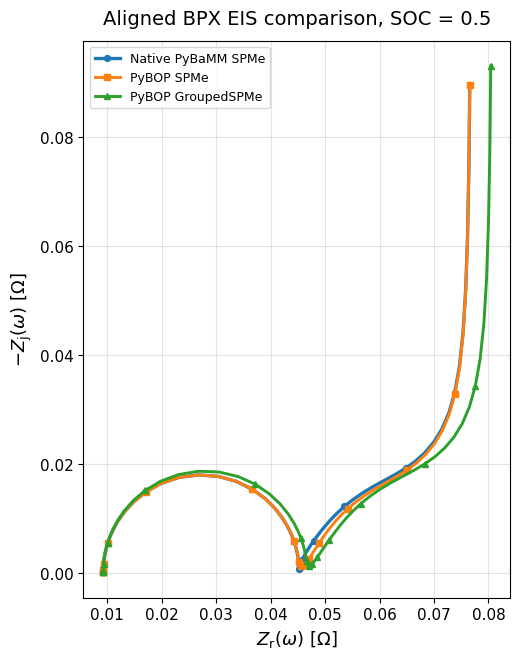


DONE
Output folder: c:\Users\mugi_jo\Documents\PYBOP_2\PyBOP\Impedance_simulation_hydra0_cell\bpx_hydra_final_vscode\result
Only the PNG figure was saved. No CSV or MAT files were written.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from bpx_hydra_config import *
from bpx_hydra_parameters import (
    make_physical_params_from_bpx,
    make_grouped_params_from_physical,
    print_parameter_summary,
    capacity_scale,
    run_native_pybamm_spme_eis,
    run_pybop_spme_eis,
    run_grouped_spme_eis,
)


# =============================================================================
# OUTPUT SETTINGS
# =============================================================================

# Save only PNG figures in a result folder next to this script.
# In normal .py scripts, __file__ exists. In Jupyter / VS Code interactive cells,
# __file__ does not exist, so we fall back to the current working directory.
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

SAVE_DIR = SCRIPT_DIR / "result"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

FIG_DPI = 300


# =============================================================================
# PLOT HELPER
# =============================================================================

def plot_aligned_eis_comparison(Z_dict, capacity_Ah, unit, soc, save_dir):
    fig, ax = plt.subplots(figsize=(8.2, 6.7))

    line_styles = ["-o", "-s", "-^", "-D"]
    line_widths = [2.4, 2.1, 2.1, 2.1]
    marker_sizes = [4.2, 3.8, 3.8, 3.8]

    unit_label = None
    unit_file = None

    for idx, (label, Z) in enumerate(Z_dict.items()):
        Zp, unit_label, unit_file = capacity_scale(Z, capacity_Ah, unit)

        n_freq = len(Zp)
        mark_every = max(1, n_freq // 16)

        ax.plot(
            np.real(Zp),
            -np.imag(Zp),
            line_styles[idx % len(line_styles)],
            linewidth=line_widths[idx % len(line_widths)],
            markersize=marker_sizes[idx % len(marker_sizes)],
            markevery=mark_every,
            label=label,
        )

    ax.set_xlabel(r"$Z_\mathrm{r}(\omega)$ [" + unit_label + "]", fontsize=13)
    ax.set_ylabel(r"$-Z_\mathrm{j}(\omega)$ [" + unit_label + "]", fontsize=13)
    ax.set_title(f"Aligned BPX EIS comparison, SOC = {soc}", fontsize=14, pad=12)

    ax.grid(True, alpha=0.35)
    ax.tick_params(axis="both", labelsize=11)
    ax.set_aspect("equal", adjustable="box")

    ax.legend(
        fontsize=9,
        frameon=True,
        loc="best",
    )

    fig.tight_layout()

    fig_path = save_dir / f"aligned_eis_comparison_{unit_file}.png"
    fig.savefig(fig_path, dpi=FIG_DPI, bbox_inches="tight")

    print("Saved:", fig_path)

    plt.show()

    return fig_path


# =============================================================================
# MAIN
# =============================================================================

frequencies = np.logspace(np.log10(FMIN), np.log10(FMAX), NFREQ)

params, diagnostics, scalar_grouping_overrides = make_physical_params_from_bpx(
    BPX_FILE,
    soc=SOC,
    contact_resistance_ohm=CONTACT_RESISTANCE_OHM,
)

grouped, grouped_metadata = make_grouped_params_from_physical(
    params,
    scalar_grouping_overrides,
    tau_ct_mode=TAU_CT_MODE,
    tau_ct_multiplier=TAU_CT_MULTIPLIER,
    use_total_area_for_grouping=USE_TOTAL_AREA_FOR_GROUPING,
    force_nominal_capacity=FORCE_NOMINAL_CAPACITY_IN_GROUPED_MODEL,
)

print_parameter_summary(params, diagnostics, grouped, grouped_metadata)

Z_pybamm = run_native_pybamm_spme_eis(
    params,
    frequencies,
    SOC,
    model_options=MODEL_OPTIONS,
)

Z_pybop = run_pybop_spme_eis(
    params,
    frequencies,
    model_options=MODEL_OPTIONS,
    var_pts=VAR_PTS,
)

Z_grouped = run_grouped_spme_eis(
    grouped,
    frequencies,
    model_options=MODEL_OPTIONS,
    var_pts=VAR_PTS,
)

capacity_Ah = params["Nominal cell capacity [A.h]"]
tau_label = grouped_metadata["tau_ct_mode"]

Z_dict = {
    "Native PyBaMM SPMe": Z_pybamm,
    "PyBOP SPMe": Z_pybop,
    # f"PyBOP GroupedSPMe ({tau_label})": Z_grouped,
    f"PyBOP GroupedSPMe": Z_grouped,
}

fig_path = plot_aligned_eis_comparison(
    Z_dict=Z_dict,
    capacity_Ah=capacity_Ah,
    unit=PLOT_UNIT,
    soc=SOC,
    save_dir=SAVE_DIR,
)

print("\nDONE")
print("Output folder:", SAVE_DIR)
print("Only the PNG figure was saved. No CSV or MAT files were written.")
